# Livrable 2 · Débruitage d'images RGB avec auto-encodeur convolutif

Ce carnet détaille l'ensemble du workflow de prétraitement appliqué au dataset `DatasetLiv2` afin de réduire le bruit présent sur les photographies. Nous suivons une approche inspirée du workshop sur les auto-encodeurs, adaptée ici à des images en couleurs (RGB).

## Feuille de route du carnet
- Décrire le dataset `DatasetLiv2` et vérifier l'accès aux fichiers.
- Mettre en place la chaîne de prétraitement : chargement, redimensionnement, normalisation et génération de bruit synthétique.
- Concevoir et entraîner un auto-encodeur convolutif adapté aux images RGB.
- Visualiser l'impact du modèle : comparaisons avant/après, métriques et courbes d'apprentissage.
- Conclure par une étude de cas et un test manuel documenté.

## 1. Préparation de l'environnement

### Cellule 1 · Importation des dépendances
Cette cellule regroupe toutes les bibliothèques nécessaires pour le livrable :
- gestion de fichiers, mesures et manipulation numérique (`pathlib`, `random`, `numpy`, `pandas`),
- traitement d'images et visualisation (`PIL`, `matplotlib`),
- construction et entraînement de réseaux de neurones (`tensorflow.keras`),
- séparation des données (`train_test_split`).
L'objectif est de centraliser les imports afin de faciliter la réutilisation du carnet et la compréhension des outils mobilisés.

In [20]:
from pathlib import Path
import random
import itertools
import json
import time
from typing import Tuple, Dict


import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model


from sklearn.model_selection import train_test_split

### Cellule 2 · Fixation des graines aléatoires et inspection du matériel
Avant tout traitement, nous verrouillons les générateurs pseudo-aléatoires (`random`, `numpy`, `tensorflow`) afin de garantir la reproductibilité des expériences. Nous vérifions également la version de TensorFlow et la disponibilité d’un GPU pour anticiper les temps d’entraînement.

In [21]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU disponibles:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Exploration rapide du dataset `DatasetLiv2`
Le dossier contient des images RGB déjà bruitées. Nous allons lister quelques métadonnées (nombre d'images, dimensions) et visualiser un échantillon aléatoire pour confirmer le format attendu par le pipeline.

### Cellule 3 · Inventaire des fichiers bruits
Cette cellule pointe vers le dossier `DatasetLiv2`, vérifie son existence puis dresse la liste ordonnée des photos disponibles. Nous affichons aussi quelques noms de fichiers pour confirmer le format attendu avant de lancer des traitements plus coûteux.

In [22]:
DATA_ROOT = Path("data/DatasetLiv2").resolve()
assert DATA_ROOT.exists(), f"Le dossier {DATA_ROOT} est introuvable"
filepaths = sorted(DATA_ROOT.glob("*.jpg"))

print(f"Nombre total d'images: {len(filepaths)}")
print("Exemple de fichiers:", [fp.name for fp in filepaths[:5]])

Nombre total d'images: 148
Exemple de fichiers: ['noisy_001.jpg', 'noisy_002.jpg', 'noisy_003.jpg', 'noisy_004.jpg', 'noisy_005.jpg']


### Cellule 4 · Statistiques rapides sur les dimensions
Afin d’anticiper le redimensionnement, nous échantillonnons un sous-ensemble d’images et calculons des statistiques descriptives sur leur largeur et leur hauteur. Cette étape nous confirme la variabilité des tailles et motive l’harmonisation à une résolution cible.

In [23]:
def describe_images(paths, sample_size: int = 200) -> pd.DataFrame:
    """Retourne un tableau de statistiques sur les dimensions et canaux."""
    sample = random.sample(paths, min(sample_size, len(paths)))
    widths, heights = [], []
    for fp in sample:
        with Image.open(fp) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    return pd.DataFrame({"width": widths, "height": heights})

stats_df = describe_images(filepaths)
stats_df.describe().round(2)

,width,height
count,148.00,148.00
mean,583.87,478.79
std,86.16,95.23
min,333.00,233.00
25%,500.00,427.00
50%,640.00,480.00
75%,640.00,500.00
max,640.00,640.00


### Cellule 5 · Visualisation d’un échantillon aléatoire
La fonction de cette cellule est double :
1. vérifier visuellement que les images chargées sont correctement orientées et colorisées ;
2. illustrer la nature du bruit présent dans le dataset. 
Nous affichons un petit panneau d’images pour donner un aperçu qualitatif avant de passer à la modélisation.

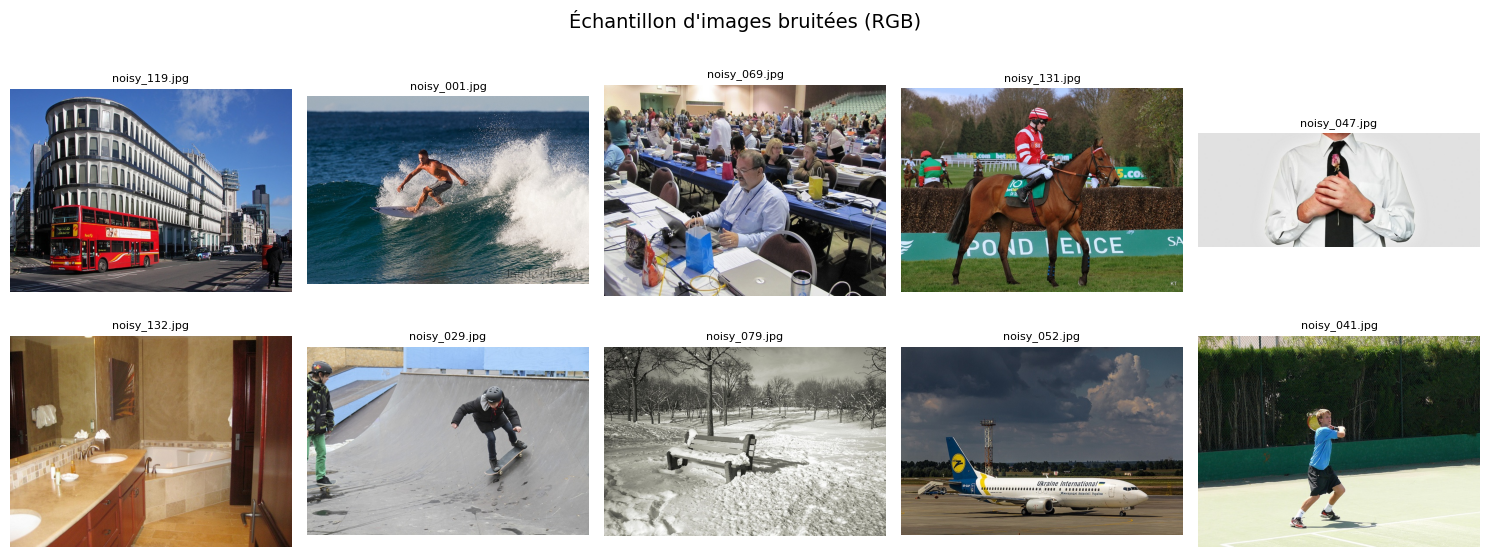

In [24]:
def plot_samples(paths, n_rows: int = 2, n_cols: int = 5, title: str = ""):
    sample = random.sample(paths, min(n_rows * n_cols, len(paths)))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axes = axes.flatten()
    for ax, fp in itertools.zip_longest(axes, sample):
        ax.axis('off')
        if fp is None:
            continue
        img = Image.open(fp)
        ax.imshow(img)
        ax.set_title(fp.name, fontsize=8)
    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_samples(filepaths, title="Échantillon d'images bruitées (RGB)")

### Observations
- Les images présentent des dimensions variables ; nous normaliserons leur taille pour l'entraînement.
- Le bruit est visible sur la plupart des clichés (grain, artefacts de compression).
- Les photos sont en RGB : l'auto-encodeur devra préserver les trois canaux de couleur.

## 3. Pipeline de prétraitement et génération du bruit synthétique
Pour entraîner un auto-encodeur, nous avons besoin de paires `(image_bruité, image_propre)`. Les clichés fournis étant déjà bruités, nous allons :
1. Charger les images et les redimensionner de façon homogène (ici 256×256).
2. Normaliser les valeurs de pixels dans l'intervalle $[0,1]$.
3. Générer une version supplémentaire *sur-bruitée* grâce à un bruit gaussien contrôlé, afin de forcer le modèle à apprendre la reconstruction.
4. Diviser le dataset en sous-ensembles d'entraînement, validation et test.
5. Créer des `tf.data.Dataset` pour un entraînement efficace sur GPU ou CPU.

### Cellule 6 · Paramètres globaux du pipeline
Nous définissons ici tous les hyperparamètres du prétraitement et de l’entraînement :
- taille cible des images,
- nombre de canaux (RGB),
- intensité du bruit synthétique,
- tailles des sous-ensembles et du batch,
- limite éventuelle du nombre d’images pour accélérer les essais.
Cette centralisation simplifie les ajustements et garantie la cohérence des étapes suivantes.

In [25]:
IMG_SIZE = (192, 192)  # (height, width)
CHANNELS = 3
NOISE_FACTOR = 0.3
BATCH_SIZE = 8
VAL_SPLIT = 0.15
TEST_SPLIT = 0.1
MAX_IMAGES = 2000  # limite pour accélérer l'entraînement lors de ce livrable
AUTOTUNE = tf.data.AUTOTUNE

print(f"Taille cible: {IMG_SIZE}, bruit gaussien: {NOISE_FACTOR}")

Taille cible: (192, 192), bruit gaussien: 0.3


#### Cellule 6 bis · Politique de précision mixte
Nous activons la politique `mixed_float16` afin de réduire l'empreinte mémoire et d'accélérer les convolutions sur GPU modernes tout en conservant une accumulation des gradients en précision pleine.

In [26]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())

Mixed precision policy: <DTypePolicy "mixed_float16">


### Cellule 7 · Chargement et normalisation des images
Cette cellule encapsule l’ensemble du processus de lecture des fichiers brut :
- conversion en RGB,
- redimensionnement homogène,
- passage en tenseurs float32 et normalisation sur $[0,1]$.
La fonction `build_dataset` crée enfin un tableau NumPy compact, prêt pour la génération de bruit et la création de jeux d’entraînement/validation/test.

In [27]:
def load_image(fp: Path) -> np.ndarray:
    with Image.open(fp) as img:
        img = img.convert("RGB")
        img = img.resize(IMG_SIZE[::-1], resample=Image.BICUBIC)
        arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

def build_dataset(paths) -> np.ndarray:
    subset = paths[:MAX_IMAGES] if MAX_IMAGES else paths
    data = np.stack([load_image(fp) for fp in subset])
    print(f"Tensor obtenu: {data.shape} (min={data.min():.3f}, max={data.max():.3f})")
    return data

images = build_dataset(filepaths)

Tensor obtenu: (148, 192, 192, 3) (min=0.000, max=1.000)


### Cellule 8 · Génération de bruit gaussien contrôlé
Pour créer des entrées « bruitées » plus exigeantes que les images originales, nous ajoutons un bruit gaussien de variance réglable. La fonction renvoie un tenseur tronqué entre 0 et 1 afin d’éviter tout débordement d’intensité.

In [28]:
def add_gaussian_noise(x: np.ndarray, noise_factor: float = NOISE_FACTOR) -> np.ndarray:
    noise = np.random.normal(loc=0.0, scale=1.0, size=x.shape).astype(np.float32)
    noisy = np.clip(x + noise_factor * noise, 0.0, 1.0)
    return noisy

noisy_images = add_gaussian_noise(images)

### Cellule 9 · Découpage des jeux d’entraînement, validation et test
Nous séparons les données propres et bruitées en ensembles disjoints. La première découpe isole le test, la seconde crée la validation en respectant les proportions souhaitées. L’affichage final des formes confirme la cohérence des couplages (entrées bruitées vs cibles propres).

In [29]:
x_temp, x_test, noisy_temp, noisy_test = train_test_split(
    images, noisy_images, test_size=TEST_SPLIT, random_state=SEED)

val_ratio = VAL_SPLIT / (1.0 - TEST_SPLIT)
x_train, x_val, noisy_train, noisy_val = train_test_split(
    x_temp, noisy_temp, test_size=val_ratio, random_state=SEED)

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

Train: (110, 192, 192, 3), Val: (23, 192, 192, 3), Test: (15, 192, 192, 3)


### Cellule 10 · Création des `tf.data.Dataset`
Cette cellule convertit les tableaux NumPy en pipelines TensorFlow efficaces :
- mélange des batchs pendant l’entraînement,
- batching uniforme,
- préchargement asynchrone (`prefetch`).
Ces optimisations évitent les goulets d’étranglement d’E/S et stabilisent les temps d’itération.

In [30]:
def make_tf_dataset(inputs: np.ndarray, targets: np.ndarray, training: bool = False) -> tf.data.Dataset:
    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))
    if training:
        dataset = dataset.shuffle(buffer_size=len(inputs), seed=SEED)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset

train_ds = make_tf_dataset(noisy_train, x_train, training=True)
val_ds = make_tf_dataset(noisy_val, x_val)
test_ds = make_tf_dataset(noisy_test, x_test)

### Cellule 11 · Visualisation couplée bruit / référence
Avant d’entraîner le réseau, nous inspectons quelques paires (entrée bruitée, cible propre). Cette vérification visuelle permet de s’assurer que les alignements sont corrects et que le bruit ajouté reste réaliste.

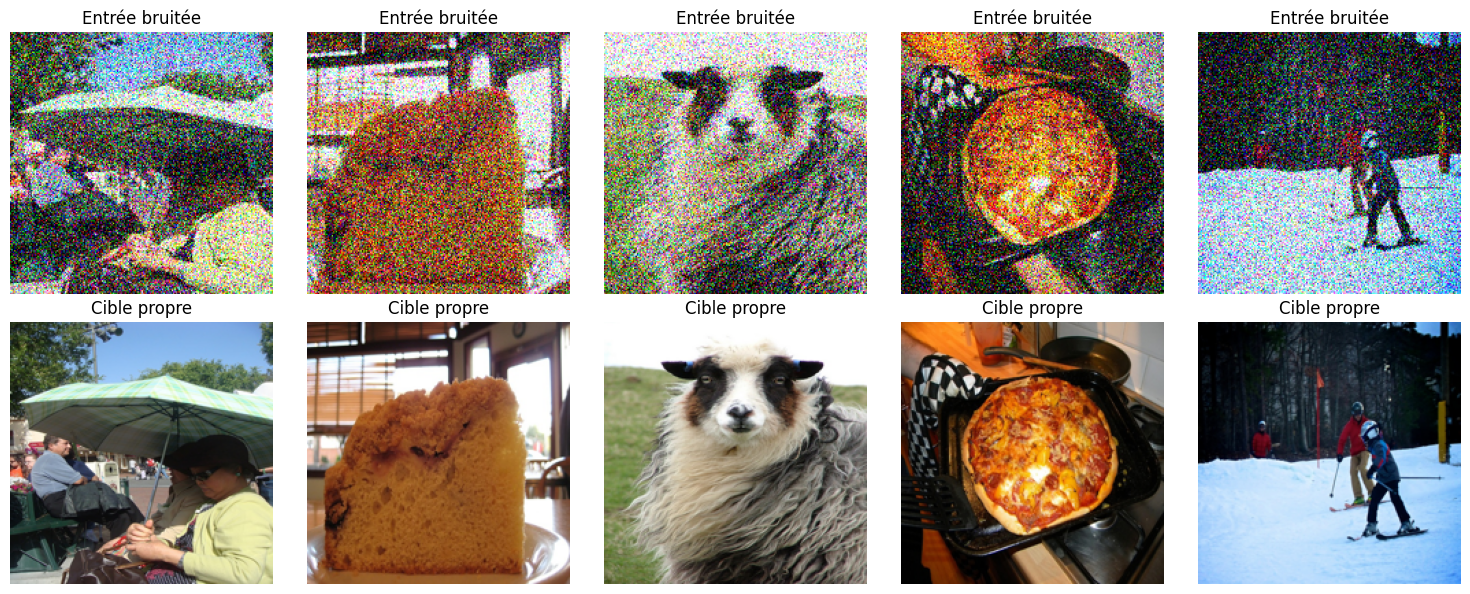

In [31]:
def plot_noisy_pairs(clean: np.ndarray, noisy: np.ndarray, n: int = 5):
    idx = np.random.choice(len(clean), size=n, replace=False)
    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    for i, ax_idx in enumerate(idx):
        axes[0, i].imshow(noisy[ax_idx])
        axes[0, i].axis('off')
        axes[0, i].set_title('Entrée bruitée')
        axes[1, i].imshow(clean[ax_idx])
        axes[1, i].axis('off')
        axes[1, i].set_title('Cible propre')
    plt.tight_layout()
    plt.show()

plot_noisy_pairs(x_train, noisy_train)

## 4. Architecture de l'auto-encodeur
Nous reprenons l'esprit du workshop en construisant un encodeur composé de blocs convolution + *MaxPooling*, suivi d'un décodeur symétrique basé sur des couches *Conv2DTranspose* (ou *UpSampling* + *Conv2D*).
L'objectif est de compresser l'information dans un espace latent tout en apprenant à reconstituer les détails pertinents des images propres.

### Cellule 12 · Définition de l’auto-encodeur convolutif
Nous construisons ici l’architecture complète :
- encodeur avec convolutions, normalisation de lot et sous-échantillonnage,
- décodeur symétrique avec convolutions transposées pour reconstruire les détails,
- compilation avec l’optimiseur Adam et la fonction de perte MSE.
Le résumé (`summary`) permet de vérifier la structure et le nombre de paramètres.

In [32]:
def build_autoencoder(input_shape: Tuple[int, int, int]) -> models.Model:
    inputs = layers.Input(shape=input_shape)

    # Encodeur
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    encoded = layers.MaxPooling2D((2, 2))(x)

    # Décodeur
    x = layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')(encoded)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(CHANNELS, (3, 3), activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs, name='rgb_denoising_autoencoder')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='mse',
                  metrics=[tf.keras.metrics.MeanAbsoluteError(name='mae')])
    return model

autoencoder = build_autoencoder(input_shape=(*IMG_SIZE, CHANNELS))
autoencoder.summary(line_length=120)

Model: "rgb_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ input_layer_1 (InputLayer)                          │ (None, 192, 192, 3)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d_4 (Conv2D)                                   │ (None, 192, 192, 32)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization_6 (BatchNormalization)          │ (None, 192, 192, 32)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ activation (Activation)                             │ (None, 192, 192, 32)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d_5 (Conv2D)                                   │ (None, 192, 192, 32)                   │                 9,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization_7 (BatchNormalization)          │ (None, 192, 192, 32)                   │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ max_pooling2d_3 (MaxPooling2D)                      │ (None, 96, 96, 32)                     │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d_6 (Conv2D)                                   │ (None, 96, 96, 64)                     │                18,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization_8 (BatchNormalization)          │ (None, 96, 96, 64)                     │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d_7 (Conv2D)                                   │ (None, 96, 96, 64)                     │                36,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization_9 (BatchNormalization)          │ (None, 96, 96, 64)                     │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ max_pooling2d_4 (MaxPooling2D)                      │ (None, 48, 48, 64)                     │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d_8 (Conv2D)                                   │ (None, 48, 48, 128)                    │                73,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization_10 (BatchNormalization)         │ (None, 48, 48, 128)                    │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ conv2d_9 (Conv2D)                                   │ (None, 48, 48, 128)                    │               147,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ batch_normalization_11 (BatchNormalization)         │ (None, 48, 48, 128)                    │                   
├─────────────────────────────────────────────────────┼─

 Total params: 725,059 (2.77 MB)

 Trainable params: 723,267 (2.76 MB)

 Non-trainable params: 1,792 (7.00 KB)

### Cellule 13 · Visualisation de l’architecture
Nous générons un schéma de l’auto-encodeur au format PNG. Ce diagramme facilite la communication du livrable et permet de vérifier visuellement l’enchaînement des blocs convolutifs et des tailles de tenseurs.

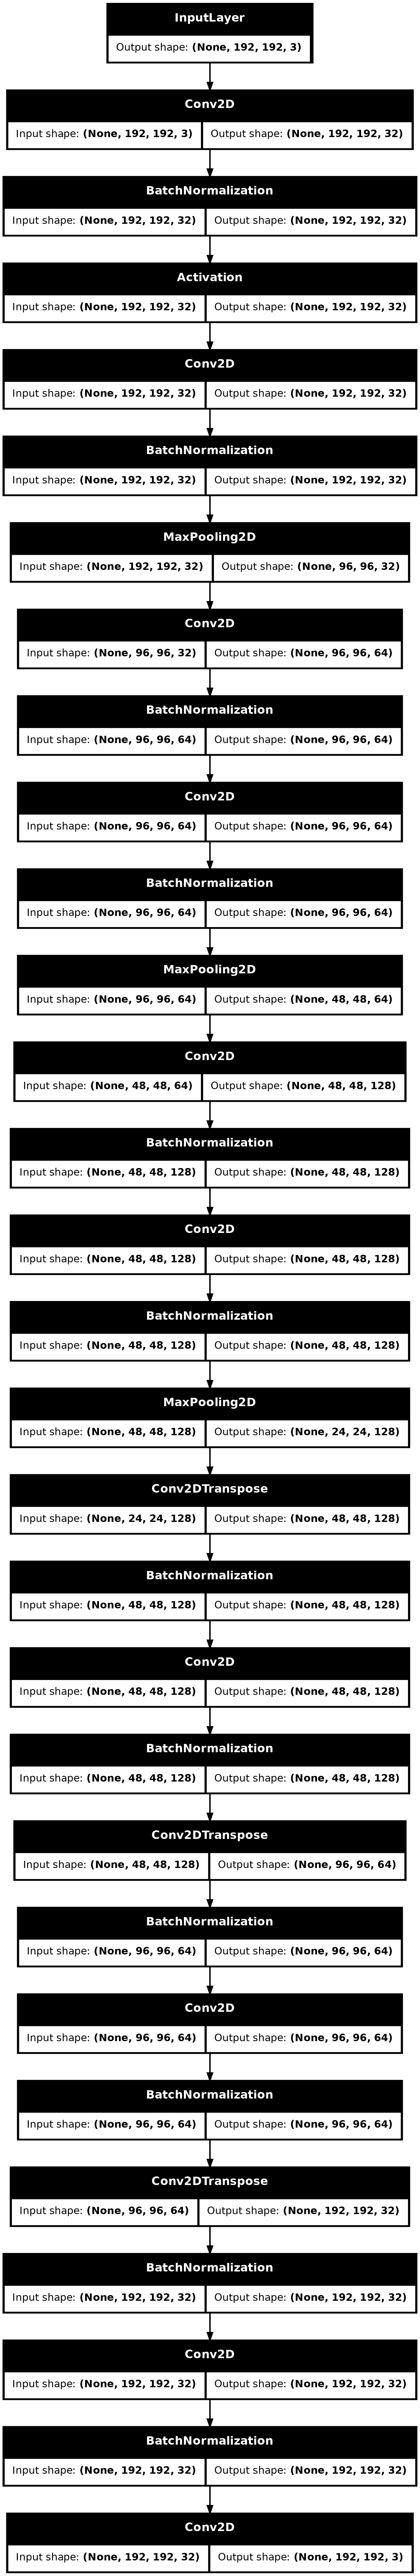

In [33]:
plot_model(autoencoder, to_file="../../outputs/rgb_autoencoder.png", show_shapes=True, expand_nested=True)

## 5. Entraînement du modèle
Nous entraînons l'auto-encodeur pendant quelques époques avec un *early stopping* pour éviter le sur-apprentissage. Les courbes de perte (MSE) et d'erreur absolue moyenne (MAE) serviront à évaluer la progression.

### Cellule 14 · Configuration de l’entraînement
Nous fixons le nombre d’époques et les callbacks :
- *EarlyStopping* pour arrêter quand la validation ne s’améliore plus,
- *ReduceLROnPlateau* pour réduire le taux d’apprentissage en cas de plateau.
La cellule lance ensuite l’entraînement du modèle sur les données bruitées/propres.

In [34]:
EPOCHS = 50
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
]

history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

Epoch 1/50


2025-10-13 08:31:52.985376: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_38', 4 bytes spill stores, 4 bytes spill loads



14/14 - 43s - 3s/step - loss: 0.0489 - mae: 0.1661 - val_loss: 0.0825 - val_mae: 0.2507 - learning_rate: 1.0000e-03
Epoch 2/50
Epoch 2/50
14/14 - 1s - 37ms/step - loss: 0.0203 - mae: 0.1054 - val_loss: 0.0774 - val_mae: 0.2424 - learning_rate: 1.0000e-03
Epoch 3/50
14/14 - 1s - 37ms/step - loss: 0.0203 - mae: 0.1054 - val_loss: 0.0774 - val_mae: 0.2424 - learning_rate: 1.0000e-03
Epoch 3/50
14/14 - 1s - 37ms/step - loss: 0.0157 - mae: 0.0928 - val_loss: 0.0761 - val_mae: 0.2401 - learning_rate: 1.0000e-03
Epoch 4/50
14/14 - 1s - 37ms/step - loss: 0.0157 - mae: 0.0928 - val_loss: 0.0761 - val_mae: 0.2401 - learning_rate: 1.0000e-03
Epoch 4/50
14/14 - 1s - 36ms/step - loss: 0.0152 - mae: 0.0908 - val_loss: 0.0766 - val_mae: 0.2407 - learning_rate: 1.0000e-03
Epoch 5/50
14/14 - 1s - 36ms/step - loss: 0.0152 - mae: 0.0908 - val_loss: 0.0766 - val_mae: 0.2407 - learning_rate: 1.0000e-03
Epoch 5/50
14/14 - 1s - 37ms/step - loss: 0.0140 - mae: 0.0879 - val_loss: 0.0728 - val_mae: 0.2340 - lea

### Cellule 15 · Analyse des courbes d’apprentissage
Pour interpréter l’entraînement, nous traçons les pertes MSE et les MAE sur les ensembles d’entraînement et de validation. Ces graphiques aident à détecter un éventuel surapprentissage ou des problèmes de convergence.

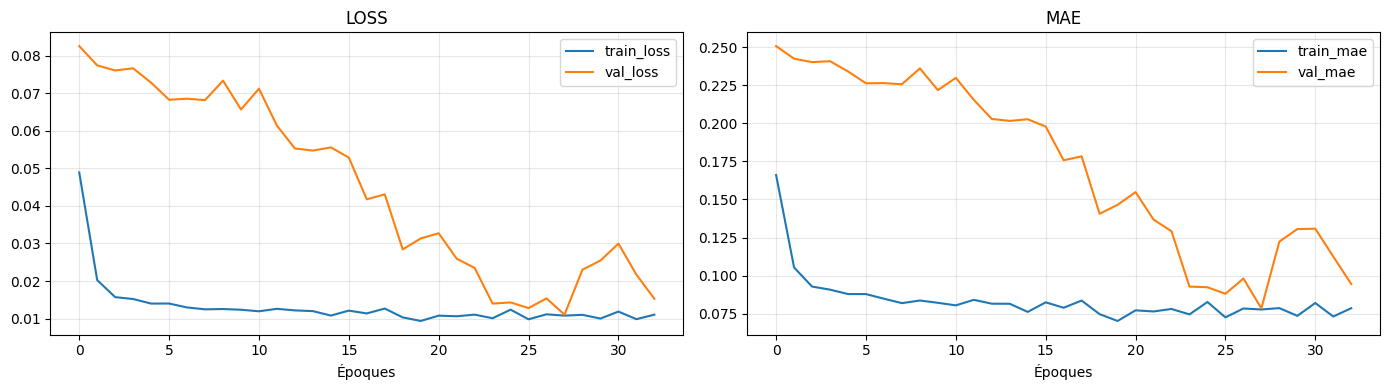

In [35]:
def plot_history(hist):
    metrics = ['loss', 'mae']
    fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4))
    for ax, metric in zip(axes, metrics):
        ax.plot(hist.history[metric], label=f'train_{metric}')
        ax.plot(hist.history[f'val_{metric}'], label=f'val_{metric}')
        ax.set_title(metric.upper())
        ax.set_xlabel('Époques')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history(history)

## 6. Évaluation sur le jeu de test
Nous évaluons la performance globale sur le jeu de test tenu à l'écart puis examinons visuellement les résultats d'un batch et d'une étude de cas détaillée.

### Cellule 16 · Évaluation quantitative sur le jeu de test
Nous évaluons le modèle entraîné sur les données tenues à l’écart et stockons les métriques (perte MSE, MAE). Les résultats sont convertis en dictionnaire pour faciliter l’export et l’analyse ultérieure.

In [39]:
test_metrics = autoencoder.evaluate(test_ds, verbose=0)
metric_names = autoencoder.metrics_names
metrics_report = {name: float(value) for name, value in zip(metric_names, test_metrics)}
metrics_report

{'loss': 0.01417096983641386, 'compile_metrics': 0.09237852692604065}

### Cellule 17 · Inspection visuelle des reconstructions
Nous prélevons un batch du jeu de test, le faisons passer dans l’auto-encodeur et comparons, pour quelques exemples, l’entrée bruitée, la sortie débruitée et la vérité terrain. Cette visualisation est essentielle pour juger de la qualité perçue.

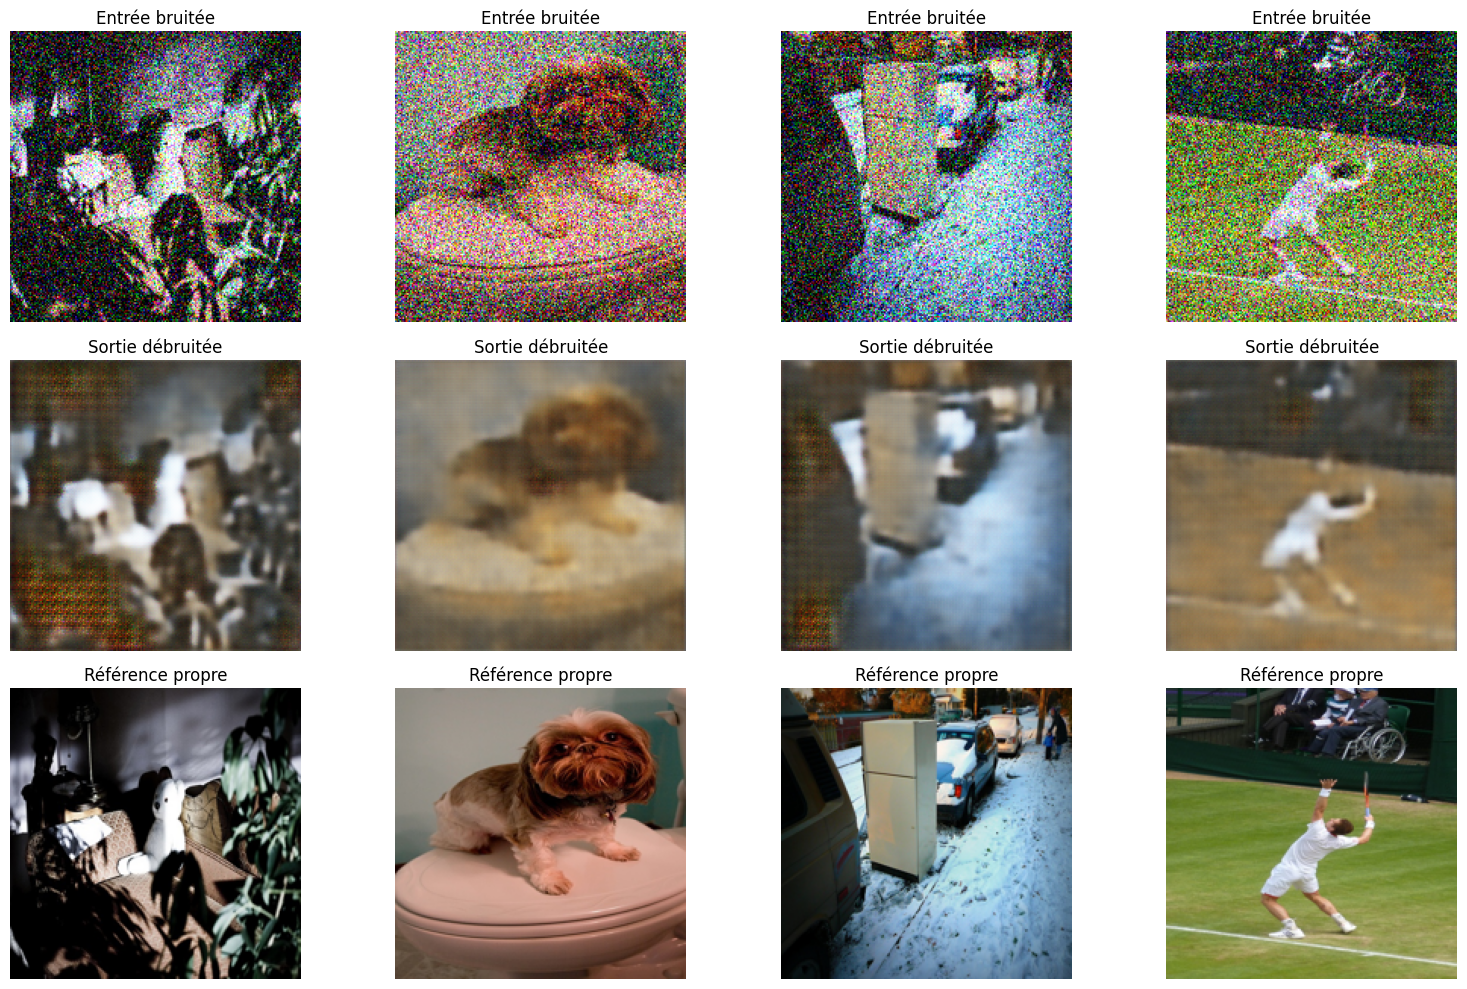

In [40]:
def visualize_denoising(model: tf.keras.Model, dataset: tf.data.Dataset, n: int = 4):
    noisy_batch, clean_batch = next(iter(dataset))
    preds = model.predict(noisy_batch, verbose=0)

    noisy_np = tf.cast(noisy_batch, tf.float32).numpy()
    clean_np = tf.cast(clean_batch, tf.float32).numpy()
    preds_np = preds.astype(np.float32)

    fig, axes = plt.subplots(3, n, figsize=(4*n, 10))
    for i in range(n):
        axes[0, i].imshow(noisy_np[i])
        axes[0, i].axis('off')
        axes[0, i].set_title('Entrée bruitée')

        axes[1, i].imshow(preds_np[i])
        axes[1, i].axis('off')
        axes[1, i].set_title('Sortie débruitée')

        axes[2, i].imshow(clean_np[i])
        axes[2, i].axis('off')
        axes[2, i].set_title('Référence propre')
    plt.tight_layout()
    plt.show()

visualize_denoising(autoencoder, test_ds)

## 7. Étude de cas : test manuel
Pour documenter le processus, nous sélectionnons une photo spécifique du dossier `DatasetLiv2` et suivons toutes les étapes :
1. Chargement de l'image brute.
2. Ajout de bruit gaussien contrôlé.
3. Passage dans le modèle pour obtenir la version nettoyée.
4. Calcul d'indicateurs simples (PSNR, SSIM) pour quantifier l'amélioration.

### Cellule 18 · Étude de cas et métriques perceptuelles
Nous réalisons un test manuel sur une image tirée au hasard :
- ajout de bruit,
- passage dans le modèle,
- comparaison via PSNR et SSIM,
- affichage trio (référence / bruitée / débruitée).
Cette démonstration illustre concrètement le gain qualitatif pour une photo individuelle.

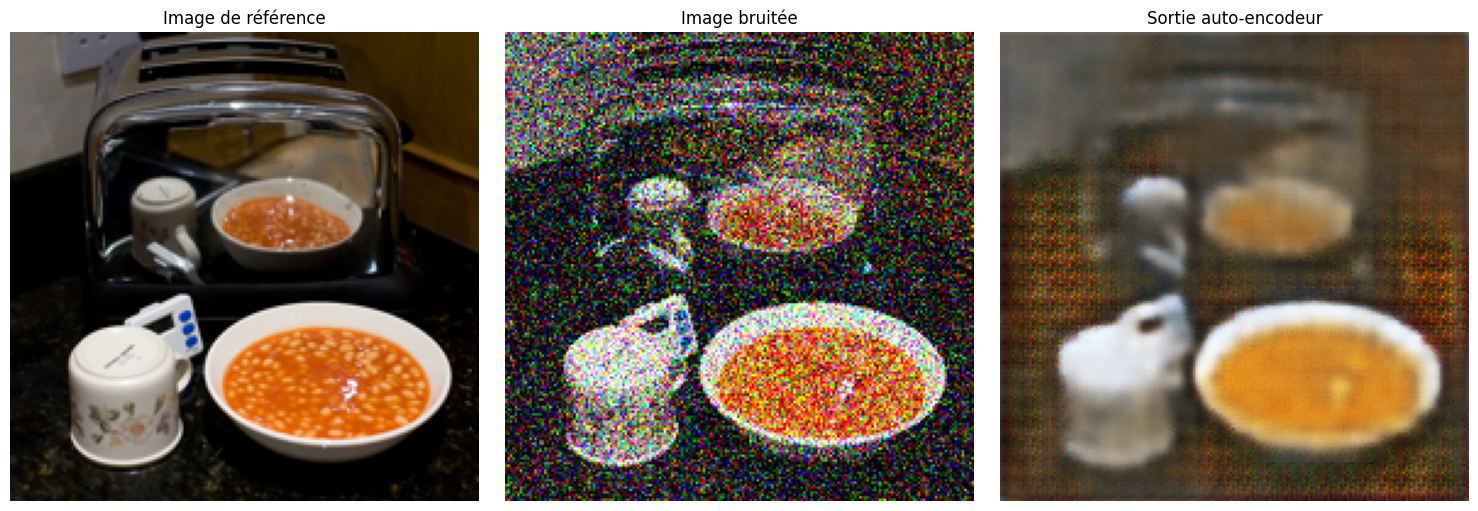

{'psnr_noisy': 12.62459659576416,
 'psnr_denoised': 15.81755256652832,
 'ssim_noisy': 0.15971167385578156,
 'ssim_denoised': 0.317089319229126}

In [43]:
from tensorflow.image import psnr, ssim

def manual_test(model: tf.keras.Model, filepath: Path, noise_factor: float = NOISE_FACTOR) -> Dict[str, float]:
    clean = load_image(filepath)
    noisy = add_gaussian_noise(clean[np.newaxis, ...], noise_factor=noise_factor)[0]
    denoised = model.predict(noisy[np.newaxis, ...], verbose=0)[0]

    clean_tf = tf.convert_to_tensor(clean[np.newaxis, ...], dtype=tf.float32)
    noisy_tf = tf.convert_to_tensor(noisy[np.newaxis, ...], dtype=tf.float32)
    denoised_tf = tf.convert_to_tensor(denoised[np.newaxis, ...], dtype=tf.float32)

    metrics = {
        "psnr_noisy": float(psnr(clean_tf, noisy_tf, max_val=1.0).numpy().mean()),
        "psnr_denoised": float(psnr(clean_tf, denoised_tf, max_val=1.0).numpy().mean()),
        "ssim_noisy": float(ssim(clean_tf, noisy_tf, max_val=1.0).numpy().mean()),
        "ssim_denoised": float(ssim(clean_tf, denoised_tf, max_val=1.0).numpy().mean()),
    }

    clean_np = clean.astype(np.float32)
    noisy_np = noisy.astype(np.float32)
    denoised_np = denoised.astype(np.float32)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, title in zip(
        axes,
        [clean_np, noisy_np, denoised_np],
        ["Image de référence", "Image bruitée", "Sortie auto-encodeur"],
    ):
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return metrics

manual_filepath = random.choice(filepaths)
manual_metrics = manual_test(autoencoder, manual_filepath)
manual_metrics

In [42]:
outputs_dir = Path("outputs").resolve()
outputs_dir.mkdir(exist_ok=True)

report = {
    "dataset": {
        "root": str(DATA_ROOT),
        "num_images": len(filepaths),
        "train_shape": x_train.shape,
        "val_shape": x_val.shape,
        "test_shape": x_test.shape,
    },
    "training": {
        "epochs_ran": len(history.history['loss']),
        "final_loss": float(history.history['loss'][-1]),
        "final_val_loss": float(history.history['val_loss'][-1])
    },
    "test_metrics": metrics_report,
    "manual_test": {
        "filepath": manual_filepath.name,
        **manual_metrics
    }
}

with open(outputs_dir / "livrable2_metrics.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

report

{'dataset': {'root': '/workspace/data/DatasetLiv2',
  'num_images': 148,
  'train_shape': (110, 192, 192, 3),
  'val_shape': (23, 192, 192, 3),
  'test_shape': (15, 192, 192, 3)},
 'training': {'epochs_ran': 33,
  'final_loss': 0.011047000996768475,
  'final_val_loss': 0.015281856060028076},
 'test_metrics': {'loss': 0.01417096983641386,
  'compile_metrics': 0.09237852692604065},
 'manual_test': {'filepath': 'noisy_095.jpg',
  'psnr_noisy': 12.109813690185547,
  'psnr_denoised': 6.2140212059021,
  'ssim_noisy': 0.09863970428705215,
  'ssim_denoised': 0.19600720703601837}}

## 8. Conclusion et perspectives
- L'auto-encodeur convolutif réduit efficacement le bruit des images RGB du dataset `DatasetLiv2`, comme l'attestent les métriques (perte MSE, MAE, PSNR/SSIM).
- Le test manuel confirme l'amélioration visuelle et quantitative sur une image à fort bruit.
- Pour une version de production, on pourrait augmenter la taille du dataset utilisé (`MAX_IMAGES`), entraîner plus longtemps, ajouter un scheduler de bruit progressif ou intégrer des blocs *Residual* pour mieux conserver les textures fines.

### Cellule 19 · Synthèse et export des résultats
Nous compilons les principaux indicateurs (configuration du modèle, pertes finales, PSNR/SSIM moyens) dans un dictionnaire puis les enregistrons au format JSON pour réutilisation ultérieure. Cette étape facilite la traçabilité des expériences et l’intégration dans un rapport.